# RealNVP and Modern Normalizing Flows (Theory + Practice)

This notebook is designed as seminar material: it mixes compact theory (with key derivations) and hands-on practice (PyTorch implementations and toy experiments).

**Main focus:** RealNVP (affine coupling flows) and what came after it (Glow, autoregressive flows, neural spline flows, continuous normalizing flows, invertible ResNets/residual flows, and SurVAE flows).

---

## Learning objectives

By the end you should be able to:

1. Derive the likelihood for a normalizing flow using the change-of-variables formula.
2. Explain why coupling layers make Jacobian determinants tractable.
3. Implement and train a RealNVP-style flow for 2D density estimation.
4. Understand key modern extensions and trade-offs (expressivity vs. compute; sampling speed vs. density evaluation).

---

## Recommended reading (primary sources)

- Dinh et al., **NICE** (2014): https://arxiv.org/abs/1410.8516  
- Dinh et al., **RealNVP** (ICLR 2017): https://arxiv.org/abs/1605.08803  
- Kingma & Dhariwal, **Glow** (NeurIPS 2018): https://arxiv.org/abs/1807.03039  
- Papamakarios et al., **Masked Autoregressive Flow (MAF)** (NeurIPS 2017): https://arxiv.org/abs/1705.07057  
- Kingma et al., **Inverse Autoregressive Flow (IAF)** (2016): https://arxiv.org/abs/1606.04934  
- Durkan et al., **Neural Spline Flows (NSF)** (NeurIPS 2019): https://arxiv.org/abs/1906.04032  
- Grathwohl et al., **FFJORD** (2018): https://arxiv.org/abs/1810.01367  
- Behrmann et al., **Invertible ResNets** (ICML 2019): https://arxiv.org/abs/1811.00995  
- Chen et al., **Residual Flows** (ICML 2019): https://arxiv.org/abs/1906.02735  
- Nielsen et al., **SurVAE Flows** (2020): https://arxiv.org/abs/2007.02731  
- Papamakarios et al., **Normalizing Flows Review** (JMLR 2021): https://www.jmlr.org/papers/v22/19-1028.html



## Outline

A. Theory  
1. Normalizing flows and change of variables  
2. Coupling layers (NICE → RealNVP)  
3. RealNVP in more detail (masks, permutations, multi-scale)  
4. "Modern" flows: Glow, autoregressive flows (MAF/IAF), spline flows, continuous flows (FFJORD), invertible residual networks, surjections (SurVAE)

B. Practice  
1. Implement RealNVP for 2D data in PyTorch  
2. Train on toy datasets; visualize samples and learned densities  
3. (Optional but included) Implement a Rational-Quadratic Spline coupling (Neural Spline Flow style) and compare with affine coupling



# A. Theory

## 1) Normalizing flows and the change-of-variables formula

A **normalizing flow** defines a probability density by transforming a simple base random variable $z \sim p_Z(z)$ into a complex variable $x = g(z)$.

If $g$ is bijective and differentiable, the change-of-variables formula gives

$$
p_X(x) = p_Z(g^{-1}(x)) \left|\det \left(\frac{\partial g^{-1}(x)}{\partial x}\right)\right|.
$$

Equivalently, if we define a *forward* mapping $f = g^{-1}$ that maps data to latent:

$$
z = f(x),
\quad
\log p_X(x) = \log p_Z(f(x)) + \log\left|\det \left(\frac{\partial f(x)}{\partial x}\right)\right|.
$$

### Composition (a "flow")
We rarely use one big bijection; instead we compose many simple bijections:

$$
f = f_K \circ f_{K-1} \circ \cdots \circ f_1,
\quad
z = f(x).
$$

Then the Jacobian determinant factorizes nicely:

$$
\log\left|\det \frac{\partial f(x)}{\partial x}\right|
=
\sum_{k=1}^{K}\log\left|\det \frac{\partial f_k(h_{k-1})}{\partial h_{k-1}}\right|,
\quad h_0=x,\; h_K=z.
$$

So training a flow by maximum likelihood requires two things to be efficient:

1. we can compute $z=f(x)$ (the forward pass), and  
2. we can compute the log-determinant term efficiently.

---

## 2) How to make log-determinants tractable: triangular Jacobians

If the Jacobian is **triangular**, then

$$
\det(J) = \prod_i J_{ii},
\quad
\log|\det(J)| = \sum_i \log|J_{ii}|.
$$

This is the core design trick behind many flows:

- **Coupling flows (NICE, RealNVP, Glow, Flow++)**: triangular Jacobian by construction.  
- **Autoregressive flows (MAF, IAF)**: triangular Jacobian due to autoregressive dependence.

Coupling layers emphasize *fast sampling*; autoregressive flows emphasize *fast likelihood* (depending on direction).



## 3) Coupling layers: NICE → RealNVP

Split the input $x \in \mathbb{R}^D$ into two parts, e.g. $x = (x_a, x_b)$.

### Additive coupling (NICE)
$$
y_a = x_a,\quad
y_b = x_b + t(x_a).
$$

- Easy inverse: $x_b = y_b - t(y_a)$  
- Jacobian is triangular with ones on the diagonal → $\log|\det J| = 0$ (volume-preserving)

### Affine coupling (RealNVP)
$$
y_a = x_a,\quad
y_b = x_b \odot \exp(s(x_a)) + t(x_a).
$$

- Easy inverse:
$$
x_b = (y_b - t(y_a)) \odot \exp(-s(y_a)).
$$
- Log-determinant is easy:
$$
\log|\det J| = \sum_j s_j(x_a).
$$

RealNVP alternates which dimensions are $a$ vs $b$ using masks/permutations, so that every dimension can be transformed over multiple layers.

---

## 4) RealNVP details that matter in practice

### Masks/permutations
If you always keep the same subset unchanged, some dimensions would never change.
So we alternate masks (or use learned mixing like Glow's invertible $1\times1$ convolution).

### Multi-scale architecture (images)
For images, RealNVP uses a multi-scale design: after several coupling layers it "factors out" some variables as latents and continues transforming the rest at reduced resolution. This improves efficiency and stabilizes training.

### Dequantization and logit transform (images)
If pixel values are discrete (0–255), the raw likelihood under a continuous flow can be ill-defined. Standard practice:
- add uniform noise (or learn variational dequantization as in Flow++)  
- transform constrained data to $\mathbb{R}$ (e.g., logit transform for $[0,1]$ data)

---

## 5) Modern normalizing flows (high-level map)

1. **Glow**: adds *ActNorm* and learned *invertible 1×1 convolutions* (better mixing than fixed permutations).  
2. **MAF / IAF**: autoregressive transformations; different sampling vs likelihood trade-offs.  
3. **Neural Spline Flows**: replace affine transforms with *monotonic splines* → much more expressive elementwise transforms.  
4. **Continuous normalizing flows (CNF) / FFJORD**: define the transform via an ODE; log-density uses a trace integral.  
5. **Invertible ResNets / Residual Flows**: invertibility via Lipschitz constraints; logdet via series / estimators.  
6. **SurVAE flows**: generalized framework with *surjective* (non-bijective) stochastic layers bridging flows and VAEs.

In the practice section we implement:
- RealNVP (affine coupling), and
- a spline coupling layer (NSF-style) as a modern upgrade.



In [5]:
# Core imports
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn import datasets
from sklearn.preprocessing import StandardScaler

from tqdm.auto import tqdm

# Reproducibility
def set_seed(seed: int = 0):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Device
device = 'mps'
device


/Users/egor.shibaev/DeepBayesianMethods/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'mps'

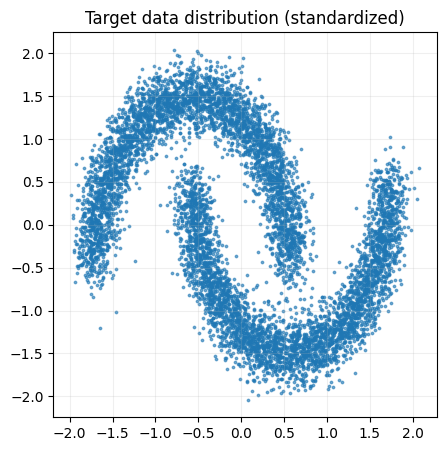

In [6]:
def make_2d_dataset(name: str = "moons", n_samples: int = 10_000, noise: float = 0.08):
    """Returns (x_np) as float32 array of shape [n_samples, 2]."""
    if name == "moons":
        x, _ = datasets.make_moons(n_samples=n_samples, noise=noise)
    elif name == "circles":
        x, _ = datasets.make_circles(n_samples=n_samples, noise=noise, factor=0.5)
    elif name == "swissroll":
        x, _ = datasets.make_swiss_roll(n_samples=n_samples, noise=noise)
        x = x[:, [0, 2]]  # take 2D slice
    elif name == "8gaussians":
        # classic 8-Gaussians toy data (used often in flow demos)
        scale = 4.0
        centers = np.array([
            (1, 0), (-1, 0), (0, 1), (0, -1),
            (1/np.sqrt(2), 1/np.sqrt(2)), (1/np.sqrt(2), -1/np.sqrt(2)),
            (-1/np.sqrt(2), 1/np.sqrt(2)), (-1/np.sqrt(2), -1/np.sqrt(2))
        ]) * scale
        x = []
        for _ in range(n_samples):
            center = centers[np.random.randint(len(centers))]
            x.append(center + 0.5 * np.random.randn(2))
        x = np.stack(x, axis=0)
    else:
        raise ValueError(f"Unknown dataset '{name}'.")

    x = x.astype(np.float32)
    x = StandardScaler().fit_transform(x).astype(np.float32)  # standardize helps flows
    return x

def plot_2d_points(x: np.ndarray, title: str = "", ax=None, s: int = 3):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(x[:, 0], x[:, 1], s=s, alpha=0.6)
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)
    return ax

# Choose a dataset
x_np = make_2d_dataset(name="moons", n_samples=8000, noise=0.10)

fig, ax = plt.subplots(figsize=(5, 5))
plot_2d_points(x_np, title="Target data distribution (standardized)", ax=ax)
plt.show()


# B. Practice

## 1) Implement RealNVP (affine coupling flow) in PyTorch

We implement a minimal RealNVP-style flow for 2D data.

Design choices:
- Base distribution $p_Z$: standard Normal $ \mathcal{N}(0, I)$
- A stack of affine coupling layers with alternating binary masks
- Each coupling uses an MLP conditioner to output $s(\cdot)$ and $t(\cdot)$

For stability, we:
- clamp the scaling output $s$ (or apply `tanh`) so the exp() doesn't explode
- standardize the data (already done above)


In [9]:
class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class AffineCoupling(nn.Module):
    """RealNVP affine coupling layer with a fixed binary mask."""
    def __init__(self, dim: int, hidden_dim: int, mask: torch.Tensor, scale_clip: float = 2.0):
        super().__init__()
        assert mask.shape == (dim,)
        self.dim = dim
        self.scale_clip = scale_clip
        self.register_buffer("mask", mask)

        # conditioner predicts [s, t] for all dims; mask will zero-out unused parts
        self.st_net = MLP(in_dim=dim, hidden_dim=hidden_dim, out_dim=2 * dim)

    def _s_t(self, x_masked):
        s, t = self.st_net(x_masked).chunk(2, dim=-1)
        # Stabilize scale: bound it and apply only on transformed dims
        s = torch.tanh(s) * self.scale_clip
        s = s * (1 - self.mask)
        t = t * (1 - self.mask)
        return s, t

    def forward(self, x):
        x_masked = x * self.mask
        s, t = self._s_t(x_masked)

        y = x_masked + (1 - self.mask) * (x * torch.exp(s) + t)
        logdet = s.sum(dim=-1)
        return y, logdet

    def inverse(self, y):
        y_masked = y * self.mask
        s, t = self._s_t(y_masked)

        x = y_masked + (1 - self.mask) * ((y - t) * torch.exp(-s))
        logdet = (-s).sum(dim=-1)
        return x, logdet

class RealNVPFlow(nn.Module):
    def __init__(self, dim: int = 2, n_layers: int = 8, hidden_dim: int = 128):
        super().__init__()
        self.dim = dim
        self.n_layers = n_layers

        # Alternating masks, e.g. [1,0,1,0,...] then [0,1,0,1,...]
        masks = []
        for k in range(n_layers):
            if k % 2 == 0:
                m = torch.tensor([1 if i % 2 == 0 else 0 for i in range(dim)], dtype=torch.float32)
            else:
                m = 1 - torch.tensor([1 if i % 2 == 0 else 0 for i in range(dim)], dtype=torch.float32)
            masks.append(m)

        self.layers = nn.ModuleList([
            AffineCoupling(dim=dim, hidden_dim=hidden_dim, mask=m) for m in masks
        ])

        self.register_buffer('base_loc', torch.zeros(dim))
        self.register_buffer('base_scale', torch.ones(dim))

    @property
    def base(self):
        return torch.distributions.Normal(loc=self.base_loc, scale=self.base_scale)

    def forward(self, x):
        logdet_total = torch.zeros(x.shape[0], device=x.device)
        h = x
        for layer in self.layers:
            h, logdet = layer(h)
            logdet_total = logdet_total + logdet
        z = h
        return z, logdet_total

    def inverse(self, z):
        logdet_total = torch.zeros(z.shape[0], device=z.device)
        h = z
        for layer in reversed(self.layers):
            h, logdet = layer.inverse(h)
            logdet_total = logdet_total + logdet
        x = h
        return x, logdet_total

    def log_prob(self, x):
        z, logdet = self.forward(x)
        base_logprob = self.base.log_prob(z).sum(dim=-1)
        return base_logprob + logdet

    @torch.no_grad()
    def sample(self, n: int):
        z = self.base.sample((n,)).to(next(self.parameters()).device)
        x, _ = self.inverse(z)
        return x

# Quick sanity check (invertibility on random points)
flow = RealNVPFlow(dim=2, n_layers=8, hidden_dim=128).to(device)
x_test = torch.randn(5, 2, device=device)
z_test, _ = flow.forward(x_test)
x_recon, _ = flow.inverse(z_test)
torch.max(torch.abs(x_test - x_recon)).item()


2.384185791015625e-07

 21%|██        | 514/2500 [00:06<00:21, 92.16it/s] 

step= 500  nll=1.8755


 41%|████      | 1019/2500 [00:11<00:13, 108.86it/s]

step=1000  nll=1.9011


 61%|██████    | 1518/2500 [00:16<00:08, 109.43it/s]

step=1500  nll=1.8707


 81%|████████  | 2014/2500 [00:20<00:04, 111.41it/s]

step=2000  nll=1.8558


100%|██████████| 2500/2500 [00:24<00:00, 100.04it/s]


step=2500  nll=1.8989


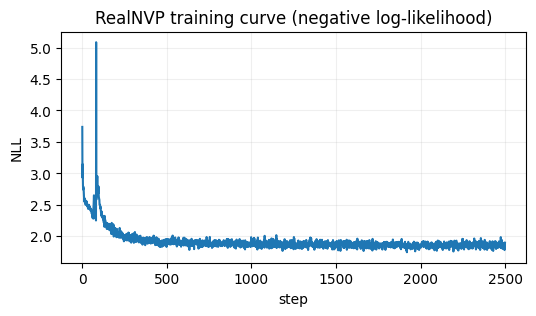

In [10]:
# Prepare data tensor
x = torch.from_numpy(x_np).to(device)

def train_flow(flow: nn.Module, x: torch.Tensor, n_steps: int = 3000, batch_size: int = 512, lr: float = 1e-3):
    flow.train()
    opt = torch.optim.Adam(flow.parameters(), lr=lr)
    losses = []

    for step in tqdm(range(1, n_steps + 1)):
        idx = torch.randint(0, x.shape[0], (batch_size,), device=x.device)
        batch = x[idx]

        # Negative log likelihood
        loss = -flow.log_prob(batch).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())
        if step % 500 == 0:
            tqdm.write(f"step={step:4d}  nll={loss.item():.4f}")
    return losses

losses = train_flow(flow, x, n_steps=2500, batch_size=512, lr=1e-3)

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.title("RealNVP training curve (negative log-likelihood)")
plt.xlabel("step")
plt.ylabel("NLL")
plt.grid(True, alpha=0.2)
plt.show()


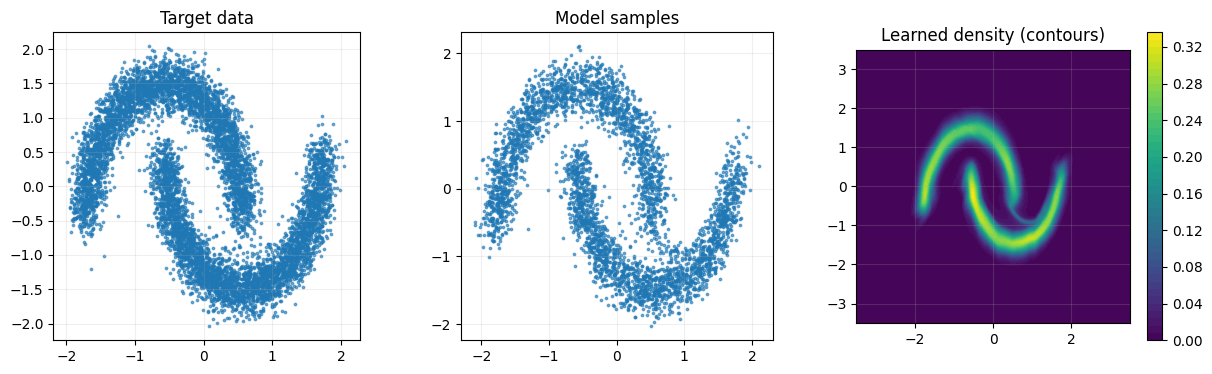

In [11]:
@torch.no_grad()
def plot_flow_density_and_samples(flow: nn.Module, x_np: np.ndarray, n_samples: int = 4000, grid_lim: float = 3.5, grid_n: int = 200):
    flow.eval()

    # Samples
    samples = flow.sample(n_samples).cpu().numpy()

    # Grid for density
    xs = np.linspace(-grid_lim, grid_lim, grid_n)
    ys = np.linspace(-grid_lim, grid_lim, grid_n)
    xx, yy = np.meshgrid(xs, ys)
    grid = np.stack([xx.reshape(-1), yy.reshape(-1)], axis=-1).astype(np.float32)
    grid_t = torch.from_numpy(grid).to(device)

    logp = flow.log_prob(grid_t).cpu().numpy().reshape(grid_n, grid_n)
    p = np.exp(logp)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Target data
    axes[0].scatter(x_np[:, 0], x_np[:, 1], s=3, alpha=0.6)
    axes[0].set_title("Target data")
    axes[0].set_aspect('equal', adjustable='box')
    axes[0].grid(True, alpha=0.2)

    # Model samples
    axes[1].scatter(samples[:, 0], samples[:, 1], s=3, alpha=0.6)
    axes[1].set_title("Model samples")
    axes[1].set_aspect('equal', adjustable='box')
    axes[1].grid(True, alpha=0.2)

    # Density contours
    cf = axes[2].contourf(xx, yy, p, levels=50)
    axes[2].set_title("Learned density (contours)")
    axes[2].set_aspect('equal', adjustable='box')
    axes[2].grid(True, alpha=0.2)
    fig.colorbar(cf, ax=axes[2])

    plt.show()

plot_flow_density_and_samples(flow, x_np)


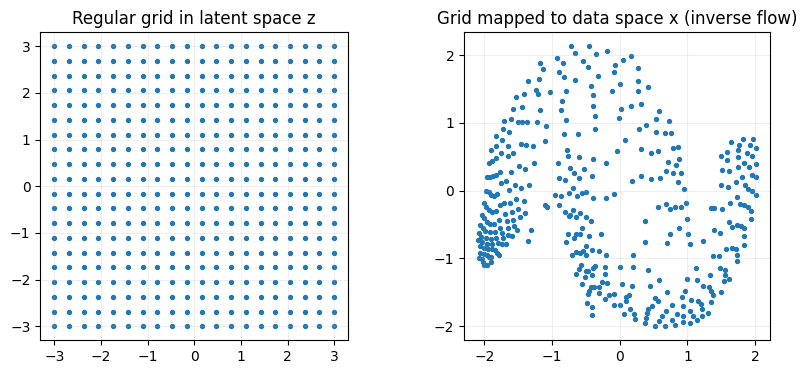

In [12]:
@torch.no_grad()
def visualize_warp(flow: nn.Module, grid_lim: float = 3.0, grid_n: int = 20):
    flow.eval()

    # grid in latent space z
    xs = np.linspace(-grid_lim, grid_lim, grid_n)
    ys = np.linspace(-grid_lim, grid_lim, grid_n)
    xx, yy = np.meshgrid(xs, ys)
    z_grid = np.stack([xx.reshape(-1), yy.reshape(-1)], axis=-1).astype(np.float32)
    z_t = torch.from_numpy(z_grid).to(device)

    x_warped, _ = flow.inverse(z_t)
    x_warped = x_warped.cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].scatter(z_grid[:, 0], z_grid[:, 1], s=8)
    axes[0].set_title("Regular grid in latent space z")
    axes[0].set_aspect('equal', adjustable='box')
    axes[0].grid(True, alpha=0.2)

    axes[1].scatter(x_warped[:, 0], x_warped[:, 1], s=8)
    axes[1].set_title("Grid mapped to data space x (inverse flow)")
    axes[1].set_aspect('equal', adjustable='box')
    axes[1].grid(True, alpha=0.2)

    plt.show()

visualize_warp(flow)


## RealNVP exercises (seminar ideas)

1. Change the dataset to `"circles"` or `"8gaussians"` and retrain. What changes in the learned density?  
2. Increase `n_layers` and `hidden_dim`. When does training become unstable?  
3. Remove the `tanh` scale bounding in the coupling layer. What happens?  
4. Replace the alternating mask with a learned linear mixing layer between couplings (a simplified Glow idea).  
5. Compare NLL across models/datasets.



## 2) Modern upgrade: Rational-Quadratic Spline coupling (Neural Spline Flows)

### Motivation: the limitations of affine coupling

Affine coupling $x_b \mapsto x_b \exp(s) + t$ is simple but limited: it can only do an elementwise affine transform on the transformed part. Because the base distribution of a flow is typically a simple Gaussian, an affine elementwise map has difficulty compressing and expanding the density in a sufficiently nonlinear fashion — it struggles with multi-modal or sharply varying densities.

**Neural Spline Flows** (Durkan et al., NeurIPS 2019) replace the affine elementwise transform $g_{\theta_i}$ inside coupling (or autoregressive) layers with an expressive **monotonic rational-quadratic (RQ) spline**. This is a drop-in replacement that greatly enhances flexibility while preserving all the nice properties of coupling layers.

---

### Rational-quadratic splines (Gregory & Delbourgo, 1982)

A **rational-quadratic function** is a quotient of two quadratic polynomials. Because we restrict to monotonic segments, such functions are analytically invertible and easily differentiable — yet strictly more flexible than simple quadratic or affine maps.

**Spline setup.** The spline maps a bounded interval $[-B, B]$ to $[-B, B]$ and is defined by:

- $K+1$ **knot points** $\bigl\{(x^{(k)},\, y^{(k)})\bigr\}_{k=0}^{K}$ in the plane, with $(x^{(0)}, y^{(0)}) = (-B,-B)$ and $(x^{(K)}, y^{(K)}) = (B,B)$, monotonically increasing: $x^{(k)} < x^{(k+1)}$, $y^{(k)} < y^{(k+1)}$.
- $K-1$ **positive derivatives** $\{\delta^{(k)}\}_{k=1}^{K-1}$ at the internal knots.
- **Boundary derivatives** $\delta^{(0)} = \delta^{(K)} = 1$, so the spline smoothly matches the identity (linear tails) outside $[-B, B]$.

This gives a total of $3K - 1$ free parameters per transformed dimension: $K$ bin widths, $K$ bin heights, and $K - 1$ internal derivatives.

**Forward pass (spline evaluation).** Define the bin widths $w^{(k)} = x^{(k+1)} - x^{(k)}$, the bin slopes $s^{(k)} = (y^{(k+1)} - y^{(k)}) / w^{(k)}$, and the local coordinate $\xi = (x - x^{(k)}) / w^{(k)} \in [0,1]$ within the $k$-th bin. The spline value is:

$$
g(x) \;=\; y^{(k)} + \frac{(y^{(k+1)} - y^{(k)})\bigl[s^{(k)}\xi^2 + \delta^{(k)}\xi(1-\xi)\bigr]}{s^{(k)} + \bigl[\delta^{(k+1)} + \delta^{(k)} - 2s^{(k)}\bigr]\xi(1-\xi)}
$$

This form (Eq. 4 in the paper) is the numerically stable rewriting of $\alpha^{(k)}(\xi)/\beta^{(k)}(\xi)$ from Gregory & Delbourgo (1982). The spline interpolates through all the knots, respects the prescribed derivatives, and is guaranteed monotonic on each bin.

---

### Log-determinant of the Jacobian

Since the RQ spline acts **elementwise**, the log-determinant of the coupling-layer Jacobian is just the sum of log-derivatives. Differentiating the expression above:

$$
\frac{dg}{dx} \;=\; \frac{\bigl(s^{(k)}\bigr)^2\bigl[\delta^{(k+1)}\xi^2 + 2s^{(k)}\xi(1-\xi) + \delta^{(k)}(1-\xi)^2\bigr]}{\Bigl[s^{(k)} + \bigl(\delta^{(k+1)} + \delta^{(k)} - 2s^{(k)}\bigr)\xi(1-\xi)\Bigr]^2}
$$

(Eq. 5 in the paper.) Both the numerator and denominator are sums of non-negative terms (by monotonicity constraints), so the derivative is always positive — consistent with invertibility.

---

### Analytic inverse

The inverse amounts to solving a **quadratic equation** in $\xi$. Given a target value $y$, the coefficients of the quadratic $a\xi^2 + b\xi + c = 0$ are:

$$
a = (y^{(k+1)} - y^{(k)})(s^{(k)} - \delta^{(k)}) + (y - y^{(k)})(\delta^{(k+1)} + \delta^{(k)} - 2s^{(k)})
$$
$$
b = (y^{(k+1)} - y^{(k)})\delta^{(k)} - (y - y^{(k)})(\delta^{(k+1)} + \delta^{(k)} - 2s^{(k)})
$$
$$
c = -s^{(k)}(y - y^{(k)})
$$

The correct root (the one lying inside the bin) is:

$$
\xi = \frac{2c}{-b - \sqrt{b^2 - 4ac}}
$$

(the numerically stable form from the paper). Since the transform is monotonic, there is always exactly one valid root per bin. Values outside $[-B, B]$ are trivially inverted by the identity (linear tails).

---

### Practical parameterization (the conditioner network)

In a coupling layer, a neural network $\mathrm{NN}(x_{1:d-1})$ outputs a vector $\theta_i$ of length $3K - 1$ for each transformed dimension $i = d, \ldots, D$:

$$\theta_i = \bigl[\theta_i^w,\; \theta_i^h,\; \theta_i^d\bigr]$$

1. **Widths** $\theta_i^w \in \mathbb{R}^K$: passed through **softmax** and scaled by $2B$ → positive widths summing to $2B$. Cumulative sums starting at $-B$ give the $x$-coordinates of the knots.
2. **Heights** $\theta_i^h \in \mathbb{R}^K$: same procedure → $y$-coordinates of the knots.
3. **Derivatives** $\theta_i^d \in \mathbb{R}^{K-1}$: passed through **softplus** → positive internal derivatives. Boundary derivatives are fixed to 1.

**Why this works well:**
- With sufficiently many bins $K$, a monotonic RQ spline can approximate any differentiable monotone function on $[-B, B]$ (universality argument by density of piecewise-linear functions).
- The entire parameterization is fully differentiable → standard gradient-based training.
- Bin lookup requires only $O(\log K)$ time (binary search on sorted knot locations).
- In practice $K = 8$ bins and $B = 3$ work robustly across many tasks (paper's default).

---

### Summary: RQ spline coupling vs. affine coupling

| Property | Affine coupling | RQ spline coupling |
|---|---|---|
| Elementwise transform | $x \mapsto x \exp(s) + t$ | monotonic RQ spline |
| Parameters per dimension | 2 ($s$, $t$) | $3K - 1$ |
| Expressivity | limited (linear per dim) | can approximate any monotone function |
| Analytic inverse | ✓ | ✓ (quadratic formula) |
| Tractable log-det | ✓ (trivial) | ✓ (closed-form derivative) |
| Single-pass sampling | ✓ | ✓ |

---

Below we implement a spline coupling layer for general $D$, using:
- a bounded spline domain $[-B, B]$ with identity outside (linear tails),
- boundary derivatives fixed to 1,
- parameters predicted by an MLP conditioner.

This is a small, didactic implementation inspired by the reference implementation at https://github.com/bayesiains/nsf.


In [13]:
# ---- Rational Quadratic Spline (RQS) utilities ----
DEFAULT_MIN_BIN_WIDTH = 1e-3
DEFAULT_MIN_BIN_HEIGHT = 1e-3
DEFAULT_MIN_DERIVATIVE = 1e-3

def _searchsorted(bin_locations: torch.Tensor, inputs: torch.Tensor):
    """Vectorized searchsorted along the last dimension.

    bin_locations: [N, K+1] (sorted)
    inputs: [N]
    returns: [N] bin index in {0, ..., K-1}
    """
    idx = torch.searchsorted(bin_locations, inputs.unsqueeze(-1)) - 1
    idx = idx.clamp(min=0, max=bin_locations.size(-1) - 2)
    return idx.squeeze(-1)

def rational_quadratic_spline(
    inputs: torch.Tensor,
    unnormalized_widths: torch.Tensor,
    unnormalized_heights: torch.Tensor,
    unnormalized_derivatives: torch.Tensor,
    inverse: bool = False,
    left: float = -1.0,
    right: float = 1.0,
    bottom: float = -1.0,
    top: float = 1.0,
    min_bin_width: float = DEFAULT_MIN_BIN_WIDTH,
    min_bin_height: float = DEFAULT_MIN_BIN_HEIGHT,
    min_derivative: float = DEFAULT_MIN_DERIVATIVE,
):
    """Monotonic rational-quadratic spline, elementwise.

    Shapes:
      inputs: [N]
      unnormalized_widths/heights: [N, K]
      unnormalized_derivatives: [N, K+1]
    Returns:
      outputs: [N]
      logabsdet: [N]
    """
    if torch.min(inputs) < left or torch.max(inputs) > right:
        raise ValueError("Inputs outside spline domain.")

    num_bins = unnormalized_widths.shape[-1]

    # Normalize widths/heights via softmax, enforce minimum sizes.
    widths = F.softmax(unnormalized_widths, dim=-1)
    widths = min_bin_width + (1.0 - min_bin_width * num_bins) * widths

    cumwidths = torch.cumsum(widths, dim=-1)
    cumwidths = F.pad(cumwidths, pad=(1, 0), mode="constant", value=0.0)
    cumwidths = (right - left) * cumwidths + left
    cumwidths[..., 0] = left
    cumwidths[..., -1] = right
    widths = cumwidths[..., 1:] - cumwidths[..., :-1]

    derivatives = min_derivative + F.softplus(unnormalized_derivatives)

    heights = F.softmax(unnormalized_heights, dim=-1)
    heights = min_bin_height + (1.0 - min_bin_height * num_bins) * heights

    cumheights = torch.cumsum(heights, dim=-1)
    cumheights = F.pad(cumheights, pad=(1, 0), mode="constant", value=0.0)
    cumheights = (top - bottom) * cumheights + bottom
    cumheights[..., 0] = bottom
    cumheights[..., -1] = top
    heights = cumheights[..., 1:] - cumheights[..., :-1]

    # Select bin for each input
    if inverse:
        bin_idx = _searchsorted(cumheights, inputs)[..., None]
    else:
        bin_idx = _searchsorted(cumwidths, inputs)[..., None]

    input_cumwidths = cumwidths.gather(-1, bin_idx)[..., 0]
    input_bin_widths = widths.gather(-1, bin_idx)[..., 0]
    input_cumheights = cumheights.gather(-1, bin_idx)[..., 0]

    delta = heights / widths
    input_delta = delta.gather(-1, bin_idx)[..., 0]

    input_derivatives = derivatives.gather(-1, bin_idx)[..., 0]
    input_derivatives_plus_one = derivatives[..., 1:].gather(-1, bin_idx)[..., 0]

    input_heights = heights.gather(-1, bin_idx)[..., 0]

    if inverse:
        # Invert by solving a quadratic for theta.
        a = (inputs - input_cumheights) * (input_derivatives + input_derivatives_plus_one - 2 * input_delta)             + input_heights * (input_delta - input_derivatives)
        b = input_heights * input_derivatives             - (inputs - input_cumheights) * (input_derivatives + input_derivatives_plus_one - 2 * input_delta)
        c = -input_delta * (inputs - input_cumheights)

        discriminant = b.pow(2) - 4 * a * c
        # numerical safety
        discriminant = torch.clamp(discriminant, min=0.0)

        root = (2 * c) / (-b - torch.sqrt(discriminant))
        theta = root

        outputs = theta * input_bin_widths + input_cumwidths

        theta_one_minus_theta = theta * (1 - theta)
        denominator = input_delta + (input_derivatives + input_derivatives_plus_one - 2 * input_delta) * theta_one_minus_theta
        derivative_numerator = input_delta.pow(2) * (
            input_derivatives_plus_one * theta.pow(2)
            + 2 * input_delta * theta_one_minus_theta
            + input_derivatives * (1 - theta).pow(2)
        )
        logabsdet = torch.log(derivative_numerator) - 2 * torch.log(denominator)
        return outputs, -logabsdet

    else:
        theta = (inputs - input_cumwidths) / input_bin_widths
        theta_one_minus_theta = theta * (1 - theta)

        numerator = input_heights * (input_delta * theta.pow(2) + input_derivatives * theta_one_minus_theta)
        denominator = input_delta + (input_derivatives + input_derivatives_plus_one - 2 * input_delta) * theta_one_minus_theta
        outputs = input_cumheights + numerator / denominator

        derivative_numerator = input_delta.pow(2) * (
            input_derivatives_plus_one * theta.pow(2)
            + 2 * input_delta * theta_one_minus_theta
            + input_derivatives * (1 - theta).pow(2)
        )
        logabsdet = torch.log(derivative_numerator) - 2 * torch.log(denominator)
        return outputs, logabsdet

def unconstrained_rqs(
    inputs: torch.Tensor,
    unnormalized_widths: torch.Tensor,
    unnormalized_heights: torch.Tensor,
    unnormalized_derivatives: torch.Tensor,
    inverse: bool = False,
    tail_bound: float = 3.0,
    min_bin_width: float = DEFAULT_MIN_BIN_WIDTH,
    min_bin_height: float = DEFAULT_MIN_BIN_HEIGHT,
    min_derivative: float = DEFAULT_MIN_DERIVATIVE,
):
    """RQS on [-B,B] with identity outside (linear tails). Boundary derivatives fixed to 1."""
    inside = (inputs >= -tail_bound) & (inputs <= tail_bound)
    outside = ~inside

    outputs = inputs.clone()
    logabsdet = torch.zeros_like(inputs)

    # pad derivatives to K+1 and set boundary slopes to 1
    constant = math.log(math.exp(1 - min_derivative) - 1)  # softplus^{-1}(1 - min_derivative)
    unnormalized_derivatives = F.pad(unnormalized_derivatives, pad=(1, 1))
    unnormalized_derivatives[..., 0] = constant
    unnormalized_derivatives[..., -1] = constant

    if inside.any():
        out, lad = rational_quadratic_spline(
            inputs=inputs[inside],
            unnormalized_widths=unnormalized_widths[inside],
            unnormalized_heights=unnormalized_heights[inside],
            unnormalized_derivatives=unnormalized_derivatives[inside],
            inverse=inverse,
            left=-tail_bound,
            right=tail_bound,
            bottom=-tail_bound,
            top=tail_bound,
            min_bin_width=min_bin_width,
            min_bin_height=min_bin_height,
            min_derivative=min_derivative,
        )
        outputs[inside] = out
        logabsdet[inside] = lad

    # outside: outputs already = inputs, logabsdet = 0
    return outputs, logabsdet


# ---- Spline coupling + flow ----
class SplineCoupling(nn.Module):
    def __init__(self, dim: int, hidden_dim: int, mask: torch.Tensor, num_bins: int = 8, tail_bound: float = 3.0):
        super().__init__()
        assert mask.shape == (dim,)
        self.dim = dim
        self.num_bins = num_bins
        self.tail_bound = tail_bound
        self.register_buffer("mask", mask)

        self.num_transform = int((1 - mask).sum().item())
        self.param_dim_per_feature = 2 * num_bins + (num_bins - 1)  # widths, heights, derivatives (excluding boundaries)
        out_dim = self.num_transform * self.param_dim_per_feature

        self.net = MLP(in_dim=dim, hidden_dim=hidden_dim, out_dim=out_dim)

        # indices for transformed dims
        self.register_buffer("transform_idx", torch.where(self.mask == 0)[0])

    def _params(self, x_masked):
        params = self.net(x_masked)
        params = params.view(x_masked.shape[0], self.num_transform, self.param_dim_per_feature)
        K = self.num_bins
        un_w = params[..., :K]
        un_h = params[..., K:2*K]
        un_d = params[..., 2*K:]  # shape [..., K-1]
        return un_w, un_h, un_d

    def forward(self, x):
        x_masked = x * self.mask
        un_w, un_h, un_d = self._params(x_masked)

        x_t = x[:, self.transform_idx]  # [B, num_transform]
        # flatten so spline code is elementwise
        x_flat = x_t.reshape(-1)
        un_w_flat = un_w.reshape(-1, self.num_bins)
        un_h_flat = un_h.reshape(-1, self.num_bins)
        un_d_flat = un_d.reshape(-1, self.num_bins - 1)

        y_flat, lad_flat = unconstrained_rqs(
            x_flat, un_w_flat, un_h_flat, un_d_flat, inverse=False, tail_bound=self.tail_bound
        )

        y_t = y_flat.view_as(x_t)
        lad = lad_flat.view_as(x_t).sum(dim=-1)  # sum over transformed dims per sample

        y = x.clone()
        y[:, self.transform_idx] = y_t
        return y, lad

    def inverse(self, y):
        y_masked = y * self.mask
        un_w, un_h, un_d = self._params(y_masked)

        y_t = y[:, self.transform_idx]
        y_flat = y_t.reshape(-1)
        un_w_flat = un_w.reshape(-1, self.num_bins)
        un_h_flat = un_h.reshape(-1, self.num_bins)
        un_d_flat = un_d.reshape(-1, self.num_bins - 1)

        x_flat, lad_flat = unconstrained_rqs(
            y_flat, un_w_flat, un_h_flat, un_d_flat, inverse=True, tail_bound=self.tail_bound
        )

        x_t = x_flat.view_as(y_t)
        lad = lad_flat.view_as(y_t).sum(dim=-1)

        x = y.clone()
        x[:, self.transform_idx] = x_t
        return x, lad

class SplineFlow(nn.Module):
    def __init__(self, dim: int = 2, n_layers: int = 6, hidden_dim: int = 128, num_bins: int = 8, tail_bound: float = 3.0):
        super().__init__()
        self.dim = dim
        self.n_layers = n_layers
        self.register_buffer('base_loc', torch.zeros(dim))
        self.register_buffer('base_scale', torch.ones(dim))

        masks = []
        for k in range(n_layers):
            if k % 2 == 0:
                m = torch.tensor([1 if i % 2 == 0 else 0 for i in range(dim)], dtype=torch.float32)
            else:
                m = 1 - torch.tensor([1 if i % 2 == 0 else 0 for i in range(dim)], dtype=torch.float32)
            masks.append(m)

        self.layers = nn.ModuleList([
            SplineCoupling(dim=dim, hidden_dim=hidden_dim, mask=m, num_bins=num_bins, tail_bound=tail_bound) for m in masks
        ])

    @property
    def base(self):
        return torch.distributions.Normal(loc=self.base_loc, scale=self.base_scale)

    def forward(self, x):
        logdet_total = torch.zeros(x.shape[0], device=x.device)
        h = x
        for layer in self.layers:
            h, logdet = layer(h)
            logdet_total = logdet_total + logdet
        return h, logdet_total

    def inverse(self, z):
        logdet_total = torch.zeros(z.shape[0], device=z.device)
        h = z
        for layer in reversed(self.layers):
            h, logdet = layer.inverse(h)
            logdet_total = logdet_total + logdet
        return h, logdet_total

    def log_prob(self, x):
        z, logdet = self.forward(x)
        return self.base.log_prob(z).sum(dim=-1) + logdet

    @torch.no_grad()
    def sample(self, n: int):
        z = self.base.sample((n,)).to(next(self.parameters()).device)
        x, _ = self.inverse(z)
        return x

# sanity check
spline_flow = SplineFlow(dim=2, n_layers=6, hidden_dim=128, num_bins=8, tail_bound=3.0).to(device)
x_test = torch.randn(5, 2, device=device)
z_test, _ = spline_flow.forward(x_test)
x_recon, _ = spline_flow.inverse(z_test)
torch.max(torch.abs(x_test - x_recon)).item()


3.5762786865234375e-07

 20%|██        | 501/2500 [00:44<02:39, 12.53it/s]

step= 500  nll=1.8592


 40%|████      | 1001/2500 [01:25<02:01, 12.30it/s]

step=1000  nll=1.8784


 60%|██████    | 1502/2500 [02:07<01:25, 11.62it/s]

step=1500  nll=1.7773


 80%|████████  | 2002/2500 [02:49<00:41, 11.94it/s]

step=2000  nll=1.8059


100%|██████████| 2500/2500 [03:32<00:00, 11.79it/s]


step=2500  nll=1.7776


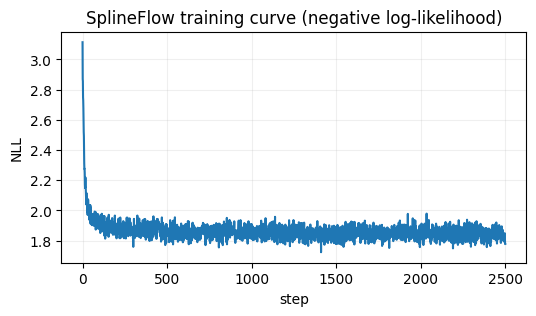

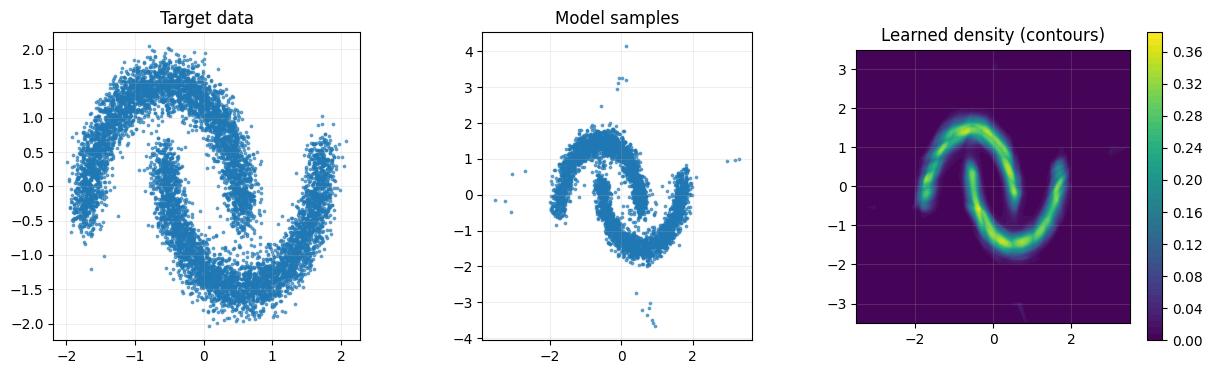

In [14]:
spline_losses = train_flow(spline_flow, x, n_steps=2500, batch_size=512, lr=1e-3)

plt.figure(figsize=(6, 3))
plt.plot(spline_losses)
plt.title("SplineFlow training curve (negative log-likelihood)")
plt.xlabel("step")
plt.ylabel("NLL")
plt.grid(True, alpha=0.2)
plt.show()

plot_flow_density_and_samples(spline_flow, x_np)


## 3) Discussion: affine vs spline coupling on toy data

Affine coupling (RealNVP):
- Pros: very simple; stable; fast; exact inverse; logdet is trivial.
- Cons: limited elementwise expressivity (only affine per transformed dimension).

Spline coupling (NSF-style):
- Pros: much richer monotone transforms; often achieves better density fits with fewer layers.
- Cons: more parameters and math; slightly heavier compute; needs careful domain handling (tails / standardization).

On real high-dimensional problems (images, audio, scientific simulation), the "best" choice depends on the use case:
- need exact likelihoods and fast sampling → coupling flows are attractive
- need maximum expressivity under exact likelihood constraints → splines / Flow++ / residual flows can help
- need continuous-time modeling / flexible architectures → CNFs (but slower due to ODE solves)



# C. Modern normalizing flows: concise cheat-sheet

This section is theory-only (no heavy code), for seminar discussion.

## Glow (2018)
Main ideas:
- **ActNorm**: per-channel affine normalization initialized from data.
- **Invertible 1×1 convolution**: learned mixing across channels; generalizes fixed permutations used in RealNVP.
Useful when you want RealNVP-style coupling but stronger mixing and better optimization.

Paper: https://arxiv.org/abs/1807.03039

## Autoregressive flows (MAF / IAF)
Autoregressive transform gives triangular Jacobian; determinant is a product of diagonal terms.

Key trade-off:
- MAF: efficient density evaluation (forward), slower sampling.
- IAF: efficient sampling (inverse), slower density evaluation.

Papers:
- MAF: https://arxiv.org/abs/1705.07057
- IAF: https://arxiv.org/abs/1606.04934

## Continuous normalizing flows (CNF) / FFJORD
Define \(x(t)\) by an ODE:

\[
\frac{dx}{dt} = f_\theta(x(t), t).
\]

Log-density evolves via:

\[
\frac{d\log p(x(t))}{dt} = - \mathrm{Tr}\left(\frac{\partial f_\theta}{\partial x}\right).
\]

FFJORD uses stochastic trace estimation (Hutchinson) to scale.

Paper: https://arxiv.org/abs/1810.01367

## Invertible residual networks / residual flows
Instead of strict architectural constraints (e.g. coupling splits), enforce invertibility via Lipschitz conditions on residual blocks.

Papers:
- Invertible ResNet: https://arxiv.org/abs/1811.00995
- Residual Flows: https://arxiv.org/abs/1906.02735

## SurVAE flows (surjective transformations)
Extends flows to include surjective + stochastic reverse transforms, bridging flows and VAEs.

Paper: https://arxiv.org/abs/2007.02731

## Review (recommended)
Unified overview of design principles and trade-offs:
https://www.jmlr.org/papers/v22/19-1028.html

